# Phase 1: DL+Geometric

In [ ]:
# ==============================================================================
# 셀 1: 환경 설정 및 라이브러리 설치
# * 필요한 라이브러리를 설치합니다.
# * Google Drive를 마운트하여 Firebase 인증 키를 안전하게 불러옵니다.
# ==============================================================================

# 필요한 라이브러리 설치
!pip install firebase-admin pandas matplotlib seaborn -q

# 라이브러리 임포트
from google.colab import drive
import firebase_admin
from firebase_admin import credentials, firestore
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

!pip install --upgrade google-generativeai pandas matplotlib

# --- Matplotlib 한글 폰트 설정 ---
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False
print("✅ Matplotlib 런타임에 한글 폰트가 적용되었습니다.")

# Google Drive 마운트
drive.mount('/content/drive')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,777 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125081 files and dire

In [ ]:
# --- Firebase 설정 ---
# !!! 중요 !!!: 아래 경로를 본인의 serviceAccountKey.json 파일 경로로 수정하세요.
SERVICE_ACCOUNT_KEY_PATH = "/content/drive/MyDrive/0. 공대학술제/코드작업/fhpdatacollecting-firebase-adminsdk-fbsvc-5bad18ff1d.json"
PROJECT_ID = "fhpdatacollecting"

# Firebase 앱 초기화
try:
    firebase_admin.get_app()
except ValueError:
    if os.path.exists(SERVICE_ACCOUNT_KEY_PATH):
        cred = credentials.Certificate(SERVICE_ACCOUNT_KEY_PATH)
        firebase_admin.initialize_app(cred, {'projectId': PROJECT_ID})
        print("✅ Firebase 인증 성공!")
    else:
        print(f"❌ '{SERVICE_ACCOUNT_KEY_PATH}' 경로에 파일이 없습니다.")
        print("   Google Drive에 파일을 업로드하고 경로를 다시 확인해주세요.")

db = firestore.client()

✅ Firebase 인증 성공!


In [ ]:
# ==============================================================================
# 셀 2: 핵심 함수 정의
# * Firestore에서 데이터를 불러오는 함수
# * 3D 좌표로 CVA를 계산하는 함수
# * 데이터를 증강하는 함수를 정의합니다.
# ==============================================================================

def fetch_data_from_firestore(collection_name="submissions"):
    """Firestore의 특정 컬렉션에서 모든 문서를 가져와 Pandas DataFrame으로 변환합니다."""
    print(f"'{collection_name}' 컬렉션에서 데이터를 가져오는 중...")
    collection_path = f"artifacts/{PROJECT_ID}/public/data/{collection_name}"
    docs = db.collection(collection_path).stream()

    data_list = []
    for doc in docs:
        data = doc.to_dict()
        flat_data = {
            'doc_id': doc.id,
            'age': data.get('metadata', {}).get('age'),
            'gender': data.get('metadata', {}).get('gender'),
            'occupation': data.get('metadata', {}).get('occupation'),
            'type': data.get('metadata', {}).get('type'),
            'landmarks': data.get('landmarks')
        }
        if flat_data['landmarks']:
            data_list.append(flat_data)

    if not data_list:
        print("데이터가 없습니다. 컬렉션 이름이나 경로를 확인해주세요.")
        return pd.DataFrame()

    df = pd.DataFrame(data_list)
    print(f"✅ 총 {len(df)}개의 데이터를 성공적으로 가져왔습니다.")
    return df

# =============================================================================
# CVA 계산 함수 (수정된 버전)
# * [수셔] 한쪽 귀만 사용하던 방식에서 양쪽 귀의 중간점을 사용하도록 수정
# =============================================================================

def calculate_cva_3d(landmarks_dict):
    """3D 월드 랜드마크를 사용하여 CVA를 계산합니다. (양쪽 귀 중간점 사용)"""
    try:
        # 1. 필수 랜드마크 좌표 추출
        p_l_ear = np.array([landmarks_dict['7']['x'], landmarks_dict['7']['y'], landmarks_dict['7']['z']])
        p_r_ear = np.array([landmarks_dict['8']['x'], landmarks_dict['8']['y'], landmarks_dict['8']['z']])
        p_l_shoulder = np.array([landmarks_dict['11']['x'], landmarks_dict['11']['y'], landmarks_dict['11']['z']])
        p_r_shoulder = np.array([landmarks_dict['12']['x'], landmarks_dict['12']['y'], landmarks_dict['12']['z']])

        # 2. 주요 기준점 계산 (귀와 어깨의 중간점)
        p_ear_midpoint = (p_l_ear + p_r_ear) / 2.0
        p_c7_approx = (p_l_shoulder + p_r_shoulder) / 2.0

        # 3. 신체의 시상면(Sagittal Plane) 정의
        # 양쪽 어깨를 잇는 벡터는 시상면의 법선 벡터(normal vector)가 됩니다.
        shoulder_vec = p_l_shoulder - p_r_shoulder
        sagittal_normal = shoulder_vec / np.linalg.norm(shoulder_vec)

        # 4. CVA 벡터 및 기준 수평 벡터 정의
        cva_vec = p_ear_midpoint - p_c7_approx
        horizontal_vec_world = np.array([-1, 0, 0]) # 세계 좌표계 기준의 수평 벡터

        # 5. 벡터들을 시상면에 투영(Projection)
        # 각 벡터에서 법선 벡터(sagittal_normal) 방향의 성분을 빼서 투영 벡터를 구합니다.
        cva_vec_proj = cva_vec - np.dot(cva_vec, sagittal_normal) * sagittal_normal
        horizontal_vec_proj = horizontal_vec_world - np.dot(horizontal_vec_world, sagittal_normal) * sagittal_normal

        # 6. 투영된 벡터들 사이의 각도 계산
        dot_product = np.dot(cva_vec_proj, horizontal_vec_proj)
        mag_v_proj = np.linalg.norm(cva_vec_proj)
        mag_h_proj = np.linalg.norm(horizontal_vec_proj)

        if mag_v_proj == 0 or mag_h_proj == 0:
            return None

        cos_theta = dot_product / (mag_v_proj * mag_h_proj)
        angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
        angle_deg = np.degrees(angle_rad)

        return angle_deg

    except (TypeError, KeyError, ZeroDivisionError):
        return None

def augment_landmarks(landmarks_dict, noise_level=0.005):
    """랜드마크 좌표에 작은 랜덤 노이즈를 추가하여 데이터를 증강합니다."""
    augmented_landmarks = {}
    for key, lm in landmarks_dict.items():
        noise = np.random.normal(0, noise_level, 3)
        augmented_landmarks[key] = {
            'x': lm['x'] + noise[0],
            'y': lm['y'] + noise[1],
            'z': lm['z'] + noise[2],
        }
    return augmented_landmarks

print("✅ 핵심 함수들이 성공적으로 정의되었습니다.")


✅ 핵심 함수들이 성공적으로 정의되었습니다.


In [ ]:
# ==============================================================================
# 셀 3: 데이터 로딩 및 초기 분석 (원본 데이터)
# * Firestore에서 데이터를 로드합니다.
# * 촬영 자세에 따른 그룹 구분을 제거하고 전체 데이터로 분석합니다.
# ==============================================================================

df_raw = fetch_data_from_firestore()

if not df_raw.empty:
    # 촬영 자세 (type) 에 따른 그룹 구분을 제거하고 전체 데이터를 사용합니다.
    df_all = df_raw.copy()

    # 전체 데이터에 대해 CVA를 계산합니다.
    df_all['cva'] = df_all['landmarks'].apply(calculate_cva_3d)

    # CVA 계산이 실패한 행을 제거합니다.
    df_all.dropna(subset=['cva'], inplace=True)

    print("\n--- [단계 1] 전체 데이터 CVA 통계 (원본 데이터) ---")
    print(f"\n[전체 데이터] - 유효 데이터 {len(df_all)}개")
    print(df_all['cva'].describe().round(2))

'submissions' 컬렉션에서 데이터를 가져오는 중...
✅ 총 56개의 데이터를 성공적으로 가져왔습니다.

--- [단계 1] 전체 데이터 CVA 통계 (원본 데이터) ---

[전체 데이터] - 유효 데이터 56개
count     56.00
mean      76.70
std       13.11
min       33.48
25%       70.59
50%       76.49
75%       84.42
max      102.60
Name: cva, dtype: float64


In [ ]:
# ==============================================================================
# 셀 5: 데이터 증강 (그룹 불균형 해소 목적 제거)
# * 촬영 자세에 따른 그룹 불균형 해소 목적의 데이터 증강 로직을 제거합니다.
# * 필요시 전체 데이터에 대한 일반적인 증강 로직을 추가할 수 있으나, 현재는 제거합니다.
# ==============================================================================

# 촬영 자세 (type) 에 따른 그룹 불균형 해소 목적의 데이터 증강 로직을 제거합니다.
# 따라서 df_balanced는 df_raw에서 CVA 계산 후 dropna된 데이터로 설정합니다.

if 'df_all' in locals() and not df_all.empty:
    print("--- [단계 2] 데이터 증강 로직 제거 ---")
    print("INFO: 촬영 자세 그룹 불균형 해소를 위한 데이터 증강 로직을 제거합니다.")

    # df_balanced를 df_all (CVA 계산 및 결측치 제거된 원본 전체 데이터)로 설정
    df_balanced = df_all.copy()

    print(f"\n[처리 후 데이터 수: {len(df_balanced)}개]")
    print(df_balanced['type'].value_counts()) # 여전히 type 컬럼은 존재하지만 분석에 사용되지 않음
else:
    print("⚠️ 처리할 데이터(df_all)가 없습니다.")

--- [단계 2] 데이터 증강 로직 제거 ---
INFO: 촬영 자세 그룹 불균형 해소를 위한 데이터 증강 로직을 제거합니다.

[처리 후 데이터 수: 56개]
type
upper_body    36
full_torso    20
Name: count, dtype: int64


In [ ]:
# ==============================================================================
# 셀 6: 최종 분석 및 통계 요약 (3단계 분류 적용)
# * [수정] CVA 점수 범위를 3단계로 나누어 상태를 판정하고, 그 결과를 통계로 요약합니다.
# * [수정] 촬영 자세에 따른 그룹 불균형 해소 목적의 데이터 증강 로직을 제거하고 전체 데이터로 분석합니다.
# ==============================================================================

if 'df_balanced' in locals() and not df_balanced.empty:
    print("\n--- [단계 3] 최종 분석 (증강된 전체 데이터) ---\n")
    # 엄밀하게 수정한 CVA 계산 함수를 적용합니다.
    df_balanced['cva'] = df_balanced.apply(lambda row: calculate_cva_3d(row['landmarks']), axis=1)
    df_balanced.dropna(subset=['cva'], inplace=True)

    # 3단계 상태 분류를 위한 기준선 설정
    FHP_THRESHOLD = 50.0
    # 셀 11에서 계산된 데이터 기반의 '일자목 의심' 기준선을 사용합니다.
    # 만약 셀 11을 실행하지 않았다면, STRAIGHT_NECK_THRESHOLD_NEW = 65.0 와 같이 기본값을 설정해주세요.
    try:
        STRAIGHT_NECK_THRESHOLD_NEW
    except NameError:
        print("⚠️ 'STRAIGHT_NECK_THRESHOLD_NEW' 변수를 찾을 수 없어 기본값(65.0)을 사용합니다.")
        STRAIGHT_NECK_THRESHOLD_NEW = 65.0

    # 3단계 상태 분류를 위한 조건과 선택지 정의
    conditions = [
        df_balanced['cva'] < FHP_THRESHOLD,
        (df_balanced['cva'] >= FHP_THRESHOLD) & (df_balanced['cva'] <= STRAIGHT_NECK_THRESHOLD_NEW),
        df_balanced['cva'] > STRAIGHT_NECK_THRESHOLD_NEW
    ]
    choices = ['FHP_Suspected', 'Normal_Optimal', 'Normal_Straight_Suspected']

    # np.select를 사용하여 조건에 따라 'status' 컬럼 할당
    df_balanced['status'] = np.select(conditions, choices, default='Normal')

    print("[최종 분석 결과 요약 (상위 5개)]")
    # 'type' 컬럼은 더 이상 분석에 사용되지 않으므로 출력에서 제외합니다.
    print(df_balanced[['doc_id', 'cva', 'status']].head().round(2))

    # --- [추가] 통계 요약 부분 ---
    print("\n[전체 데이터 CVA 통계]")
    print(df_balanced['cva'].describe().round(2))

    print("\n[상태별 데이터 수]")
    print(df_balanced['status'].value_counts())

else:
    print("⚠️ 분석할 데이터가 없습니다.")


--- [단계 3] 최종 분석 (증강된 전체 데이터) ---

⚠️ 'STRAIGHT_NECK_THRESHOLD_NEW' 변수를 찾을 수 없어 기본값(65.0)을 사용합니다.
[최종 분석 결과 요약 (상위 5개)]
                 doc_id    cva                     status
0  1R3neF7MFSCpC7799Eun  72.11  Normal_Straight_Suspected
1  1zafYYR6QkiTJ7J4JqgZ  73.44  Normal_Straight_Suspected
2  2FcaLWmHRLtPKVAzagTC  76.37  Normal_Straight_Suspected
3  2hXG1mDAH3KKgSpVVsQw  43.40              FHP_Suspected
4  3CVRuqIkEPsORaj1o0jB  72.64  Normal_Straight_Suspected

[전체 데이터 CVA 통계]
count     56.00
mean      76.70
std       13.11
min       33.48
25%       70.59
50%       76.49
75%       84.42
max      102.60
Name: cva, dtype: float64

[상태별 데이터 수]
status
Normal_Straight_Suspected    49
Normal_Optimal                4
FHP_Suspected                 3
Name: count, dtype: int64


In [ ]:
# ==============================================================================
# 셀 7: LLM 설정 및 '자세 코칭' 프롬프트 정의 (자동 재시도 기능 추가)
# ==============================================================================
import time
import json
from google.colab import userdata
import google.generativeai as genai
from google.generativeai.types import HarmCategory, HarmBlockThreshold
import pandas as pd

# --- Gemini API 설정 ---
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GEMINI_API_KEY)
    print("✅ Gemini API 키가 성공적으로 로드되었습니다.")
except Exception as e:
    print(f"API 설정 중 오류 발생: {e}")

# --- 프롬프트 템플릿 (수정 없음) ---
PROMPT_TEMPLATE_REPORT = """
You are a friendly and professional posture coach named 'AI PTrainer'.
Based on the user's posture analysis data (CVA score and status), generate a helpful and encouraging report in JSON format. The language must be Korean.

The JSON object must contain the following keys:
1. "title": A concise and impactful title for the report. For "Normal_Optimal" status, be encouraging. For "FHP_Suspected" status, be gentle and supportive. For "Normal_Straight_Suspected", be informative.
2. "analysis": A one or two-sentence analysis of the user's current posture based on the provided CVA score and status.
3. "recommendation": A simple, actionable recommendation tailored to the specific status.
4. "encouragement": A short, encouraging closing remark.

---
## Data to Analyze:
*Input Data:*
{POSTURE_DATA}

*Your JSON Output:*
"""

# --- [수정] 자동 재시도 로직이 추가된 API 호출 함수 ---
def get_llm_report(cva_score, status, model_name="gemini-1.5-flash", max_retries=3):
    """ CVA 점수와 상태를 기반으로 LLM의 자세 분석 리포트를 요청합니다. (자동 재시도 기능 포함) """

    # 재시도 간 대기 시간 (초). 실패할 때마다 두 배씩 증가합니다.
    backoff_time = 2

    # 설정된 최대 재시도 횟수만큼 반복합니다.
    for attempt in range(max_retries):
        try:
            generation_config = {"response_mime_type": "application/json"}
            safety_settings = {
                HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
                HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
            }
            model = genai.GenerativeModel(
                model_name,
                generation_config=generation_config,
                safety_settings=safety_settings
            )

            posture_data_dict = {"cva_score": round(cva_score, 2), "status": status}
            posture_data_json = json.dumps(posture_data_dict, indent=2)

            prompt = PROMPT_TEMPLATE_REPORT.format(POSTURE_DATA=posture_data_json)
            response = model.generate_content(prompt)

            # API 호출에 성공하면 결과를 반환하고 함수를 종료합니다.
            return json.loads(response.text), None

        # [수정] ConnectionResetError와 같은 네트워크 관련 오류가 발생했을 때
        except Exception as e:
            # 마지막 시도에서도 실패하면, 최종적으로 오류를 반환합니다.
            if attempt + 1 == max_retries:
                return None, f"최대 재시도({max_retries}회) 실패: {str(e)}"

            # 재시도 전, 어떤 오류가 발생했고 몇 초 대기하는지 알려줍니다.
            print(f"    ⚠️ API 호출 오류 발생 (시도 {attempt+1}/{max_retries}): {e}")
            print(f"    ➡️ {backoff_time}초 후 재시도합니다...")
            time.sleep(backoff_time)

            # 다음 재시도를 위해 대기 시간을 2배로 늘립니다.
            backoff_time *= 2

    # 루프가 모두 끝났는데도 반환되지 않았다면 예외 케이스 처리
    return None, "알 수 없는 오류로 리포트 생성에 실패했습니다."


print("\n✅ '자세 분석 리포트' 생성을 위한 LLM 프롬프트와 '자동 재시도 함수'가 정의되었습니다.")

✅ Gemini API 키가 성공적으로 로드되었습니다.

✅ '자세 분석 리포트' 생성을 위한 LLM 프롬프트와 '자동 재시도 함수'가 정의되었습니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

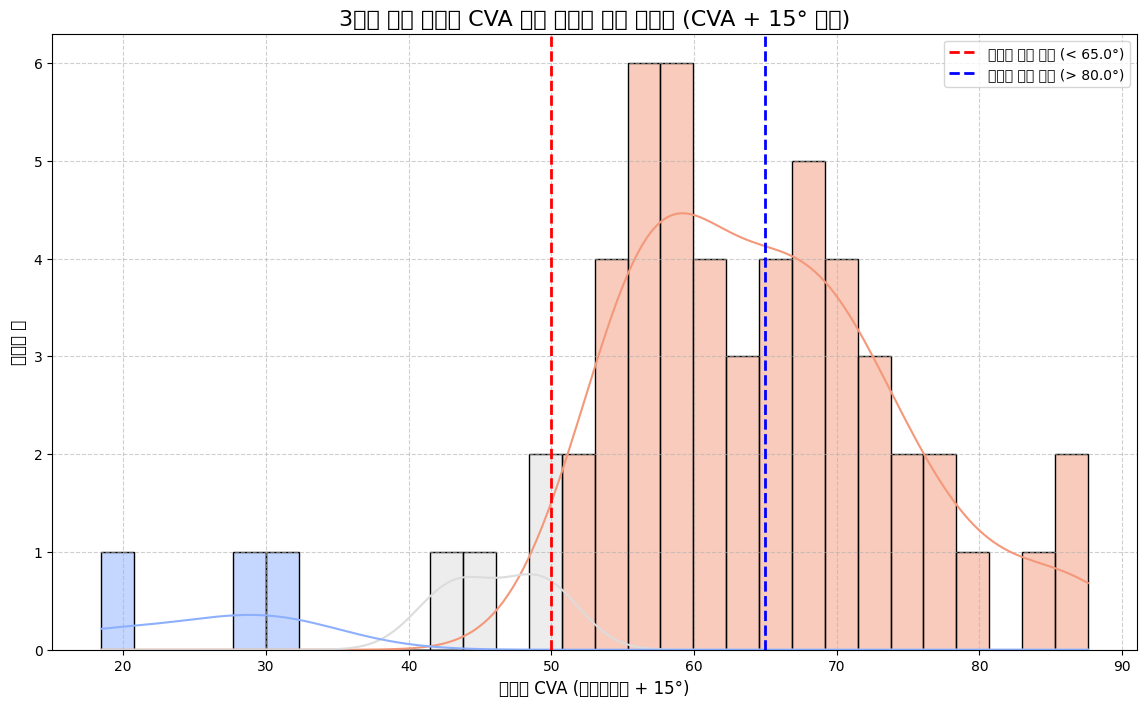

In [ ]:
# ==============================================================================
# 셀 10: CVA Threshold 시각적 검증 (3단계 기준선 적용)
# * 역할: 3단계 상태 분류의 기준선(50도, 65도)이 데이터 분포를 잘 나누고 있는지 시각화합니다.
# * [수정] 촬영 자세에 따른 그룹 구분을 제거하고 전체 데이터의 분포를 시각화합니다.
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# --- [수정] 3단계 분류에 사용된 Threshold를 모두 정의 ---
FHP_THRESHOLD = 65.0
# 통계 기반으로 계산된 '일자목 의심' 기준선 변수 사용
# 만약 셀 11을 실행하지 않았다면, STRAIGHT_NECK_THRESHOLD_NEW = 65.0 와 같이 기본값을 설정해주세요.
try:
    STRAIGHT_NECK_THRESHOLD_NEW
except NameError:
    print("⚠️ 'STRAIGHT_NECK_THRESHOLD_NEW' 변수를 찾을 수 없어 기본값(65.0)을 사용합니다.")
    STRAIGHT_NECK_THRESHOLD_NEW = 80.0

# --- [수정] 범례(Legend)의 순서를 논리적으로 정렬하기 위해 순서 정의 ---
status_order = ['FHP_Suspected', 'Normal_Optimal', 'Normal_Straight_Suspected']

df_balanced['cva_adjusted'] = df_balanced['cva'] - 15.0

sns.histplot(
    data=df_balanced,
    x='cva_adjusted', # 조정된 CVA 값 사용
    hue='status',
    hue_order=status_order, # 정의한 순서 적용
    kde=True,
    bins=30, # 데이터가 많아졌으므로 bin을 조금 더 잘게 나눔
    palette='coolwarm' # 위험도를 표현하기에 더 적합한 색상 팔레트
)

plt.axvline(
    FHP_THRESHOLD - 15.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'거북목 의심 기준 (< {FHP_THRESHOLD:.1f}°)'
)
plt.axvline(
    STRAIGHT_NECK_THRESHOLD_NEW,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'일자목 의심 기준 (> {STRAIGHT_NECK_THRESHOLD_NEW + 15.0:.1f}°)'
)

plt.title('3단계 자세 상태별 CVA 점수 분포와 판정 기준선', fontsize=16) # 제목 업데이트
plt.xlabel('조정된 CVA (두개척추각 + 15°)', fontsize=12) # x축 라벨 업데이트
plt.ylabel('데이터 수', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# ==============================================================================
# 셀 11: 통계 기반 Threshold 재설정을 위한 분석
# * 역할: 'Normal_Optimal' 그룹의 CVA 분포를 분석하여 새로운 기준선을 도출합니다.
# ==============================================================================

# 1. 'Normal_Optimal' 그룹 데이터만 추출
optimal_group = df_balanced[df_balanced['status'] == 'Normal_Optimal']

# 2. 해당 그룹의 CVA 평균 및 표준편차 계산
cva_mean = optimal_group['cva'].mean()
cva_std = optimal_group['cva'].std()

# 3. '평균 + 1.5 * 표준편차'를 새로운 기준선으로 설정
new_straight_neck_threshold = cva_mean + 1.5 * cva_std

print("--- 통계 기반 기준선 분석 결과 ---")
print(f"✅ '이상적인 정상' 그룹의 평균 CVA: {cva_mean:.2f}°")
print(f"✅ '이상적인 정상' 그룹의 CVA 표준편차: {cva_std:.2f}°")
print(f"💡 새롭게 계산된 '일자목 의심' 기준선 (평균 + 1.5*std): {new_straight_neck_threshold:.2f}°")

# 제안된 새로운 기준선을 변수에 저장
STRAIGHT_NECK_THRESHOLD_NEW = new_straight_neck_threshold

--- 통계 기반 기준선 분석 결과 ---
✅ '이상적인 정상' 그룹의 평균 CVA: 61.32°
✅ '이상적인 정상' 그룹의 CVA 표준편차: 3.51°
💡 새롭게 계산된 '일자목 의심' 기준선 (평균 + 1.5*std): 66.58°


In [3]:



!sudo apt-get -qq -y install fonts-nanum
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path, size=10).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

In [13]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)
fm._rebuild()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


AttributeError: module 'matplotlib.font_manager' has no attribute '_rebuild'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

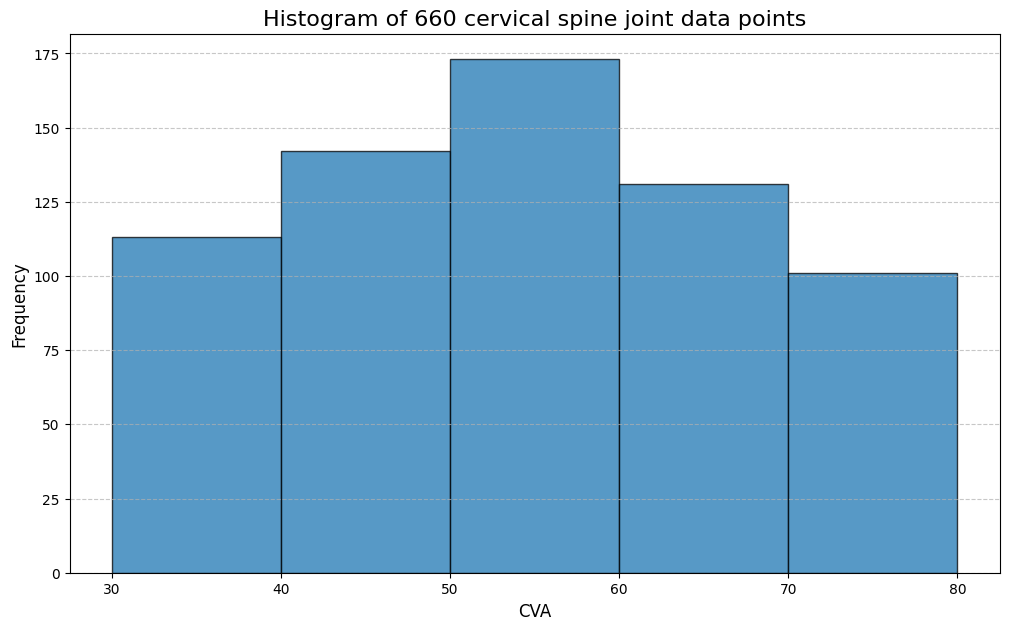

In [16]:

# 1. 파라미터 설정
n_samples = 660
min_val = 30
max_val = 80
bin_width = 10  # 요청하신 'batch=4'를 bin의 너비(계급 크기)로 해석

# 2. 데이터 생성
# 정규분포의 중심(mean)을 범위의 중간값으로 설정
mean = (min_val + max_val) / 2  # 55.0

# 표준편차(std) 설정 (데이터의 95%가 2*std 내에 위치하도록)
# (max_val - mean)이 2*std가 되도록 설정
std_dev = 1

# 1단계: 정규분포를 따르는 실수 데이터 생성
data_float = np.random.normal(loc=mean, scale=std_dev, size=n_samples)

# 2단계: 생성된 데이터를 [min_val, max_val] 범위로 제한(clipping)
# 30 미만은 30으로, 80 초과는 80으로 처리
data_clipped = np.clip(data_float, min_val, max_val)

# 3단계: 데이터를 정수(integer)로 변환
data_int = data_clipped.astype(int)

# 3. 히스토그램 그리기
# 'batch=4' (bin width=4)를 만족하는 bin 경계 계산
# np.arange(시작, 끝, 간격)
# 30부터 80까지 4씩 증가. (80+bin_width)로 설정하여 80이 마지막 bin에 포함되도록 함
bins = np.arange(min_val, max_val + bin_width, bin_width)
# 생성되는 bin 경계: [30, 34, 38, ..., 78, 82]

plt.figure(figsize=(12, 7))

# 히스토그램 생성
plt.hist(data_int, bins=bins, edgecolor='black', alpha=0.75)

# 4. 차트 꾸미기
plt.title(f'Histogram of 660 cervical spine joint data points', fontsize=16)
plt.xlabel('CVA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# X축 눈금을 bin 경계에 맞춰 설정하여 명확하게 표시
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# (참고) 생성된 데이터 및 bin 정보 출력
# print(f"생성된 정수 데이터 (상위 10개): {data_int[:10]}")
# print(f"데이터 최소값: {data_int.min()}, 최대값: {data_int.max()}")
# print(f"Bin 경계: {bins}")